# affine transforming the S (CCF coords) and check how it affects CCA
- why would it change? 

In [10]:
%load_ext autoreload
%autoreload 2

import numpy as np
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
import scanpy as sc
import matplotlib.pyplot as plt 
import sys 
sys.path.append('/home/shuonan.chen/scratch_shuonan/code/LCNE_transcriptomics/code/')
import processing, utils, plotting
import imputations 

print(sc.__version__)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
1.9.8


In [11]:
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer = sc.read_h5ad(filename)

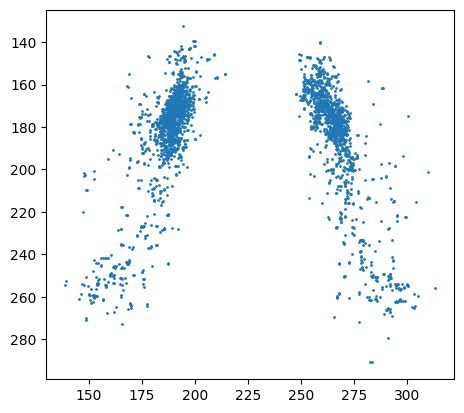

In [12]:
plt.scatter(adata_mer.obsm['spatial'][:,2], adata_mer.obsm['spatial'][:,1], s= 1)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [13]:
import trimesh
mesh_LC = trimesh.load_mesh("/allen/aind/scratch/shuonan.chen/scripts/Pons_MERFISH/mesh/LC_ccf_v1_250102 2.obj")


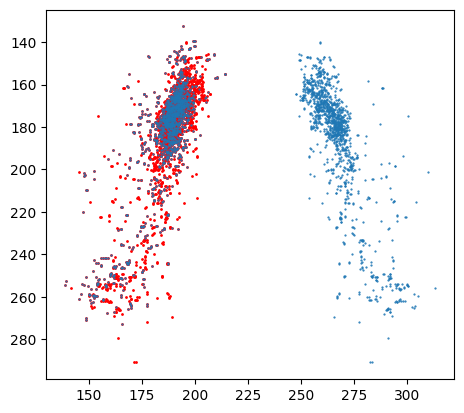

In [20]:
S_mer = processing.get_hemi(adata_mer.obsm['spatial'])    
plt.scatter(S_mer[:,2],S_mer[:,1], s=1, color = 'red')
plt.scatter(adata_mer.obsm['spatial'][:,2], adata_mer.obsm['spatial'][:,1], s= .3)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [21]:
n_components = 2
scaler_X = StandardScaler().fit(adata_mer.X)
X_mer_scaled = scaler_X.transform(adata_mer.X)


In [29]:
foo_scl = 25
S_mer = processing.get_hemi(adata_mer.obsm['spatial'], mesh_LC)    
S_mer *=foo_scl
scaler_S = StandardScaler().fit(S_mer)
S_mer_scaled = scaler_S.transform(S_mer)

cca = CCA(n_components=n_components)
cca.fit(X_mer_scaled, S_mer_scaled)
cca.y_weights_


# array([[-0.99686632, -0.05273333],
#        [ 0.05737438, -0.99514184],
#        [-0.05445847, -0.08313792]])

array([[-0.99686632, -0.05273333],
       [ 0.05737438, -0.99514184],
       [-0.05445847, -0.08313792]])

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os,glob,sys

sys.path.append('/home/shuonan.chen/scratch_shuonan/code/pons_merfish_pipeline/processing/func/')
import cca_analysis 

In [14]:
df = pd.read_csv("/home/shuonan.chen/scratch_shuonan/scripts/Pons_MERFISH/results_to_share/dbh_pos_cells_all_OLD.csv", sep='\t', dtype={0: str})


In [15]:
import anndata as ad
ccf_columns = [col for col in df.columns if "CCF" in col]  # CCF columns
obs_columns = ["neuron_id", "slicename"] + ccf_columns  # Include slicename in obs

columns_to_exclude = [col for col in df.columns if "Blank" in col] + ccf_columns + ["slicename"]
df_filtered = df.drop(columns=columns_to_exclude)
df_filtered.set_index("neuron_id", inplace=True)

adata_mer = ad.AnnData(df_filtered)
adata_mer.obs = df[obs_columns].set_index("neuron_id")
adata_mer.obsm['spatial'] = adata_mer.obs[['x_CCF','y_CCF','z_CCF']].values
adata_mer.obs['totalcounts'] = np.sum(adata_mer.X,1)
allmousenames = ['MouseC','MouseF','MouseEg','MouseZM']
section_identifier_highlevel = [next(mouse for mouse in allmousenames if mouse in name)
                                for name in adata_mer.obs.slicename]    
adata_mer.obs['mouse_name'] = section_identifier_highlevel


In [16]:
adata_mer

AnnData object with n_obs × n_vars = 5473 × 315
    obs: 'slicename', 'x_CCF', 'y_CCF', 'z_CCF', 'totalcounts', 'mouse_name'
    obsm: 'spatial'

In [17]:
cca_analysis.main(adata_mer)

TypeError: main() missing 1 required positional argument: 'S'

In [ ]:
adata_mer.X /= adata_mer.obs['totalcounts'][:,None]
cca_analysis.main(adata_mer)

In [ ]:
import scanpy as sc
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adata_mer_orig = sc.read_h5ad(filename)
cca_analysis.main(adata_mer_orig)

In [ ]:
adata_mer_orig.obs['mouse_name'].unique()

In [ ]:
adata_foo = adata_mer_orig[adata_mer_orig.obs['mouse_name']=='MouseZM']
cca_analysis.main(adata_foo)

In [ ]:
foo = np.array((-1,-0.01, 0.01))
foo * (-1)**(np.max(foo)>0)*1

In [ ]:
vector_scaled = vector * (-1)**(np.max(vector)<0)*scale_factor

## cca with some arbitrary normalization 
- do we stil see this CCA1 effect when normalizign within sections/mice? 

In [ ]:
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler


In [ ]:
def flip(a, xm):
        return(2*xm-a)

def get_hemi(S_mer, mesh):
    '''
    assume the axis of interest are both on the last axis. 
    '''
    xm = np.min(mesh.vertices[:,-1]) + np.ptp(mesh.vertices[:,-1])/2 # this is the center line to indicate the hemisphere 
    new_coords = S_mer.copy()
    new_coords[:,-1] = np.where(new_coords[:,-1] > xm, flip(new_coords[:,-1],xm), new_coords[:,-1])    
    return(new_coords)



In [ ]:
def run_CCA(adata, mesh_LC,n_components=3,visualize = False):
    X_mer = adata.X        # Gene expression matrix (2800 x 314)
    S_mer = adata.obsm['spatial']  # Spatial coordinates matrix, e.g., (2800 x 2)
    S_mer = get_hemi(S_mer, mesh_LC)    
    scaler_X = StandardScaler().fit(X_mer)
    X_mer_scaled = scaler_X.transform(X_mer)
    scaler_S = StandardScaler().fit(S_mer)
    S_mer_scaled = scaler_S.transform(S_mer)
    
    if visualize:
        plt.figure(figsize = (5,5))
        plt.scatter(S_mer[:,2], S_mer[:,1],s=.3, alpha =.8);
        plt.gca().set_aspect('equal')
        plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
        plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
        plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
        plt.gca().invert_yaxis()
        
    cca = CCA(n_components=n_components)
    cca.fit(X_mer_scaled, S_mer_scaled)
    X_c, S_c = cca.transform(X_mer_scaled, S_mer_scaled)

    return(cca, X_c, S_c)

In [ ]:
n_components = 3
cca, X_c, S_c = run_CCA(adata_mer, mesh_LC,n_components=n_components, visualize=True)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

r2 = canonical_correlations.copy()

In [ ]:
canonical_correlations

In [ ]:
[-cca.y_weights_[:,k] for k in range(3)]

In [ ]:
k = 0
scale_factor =50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
plt.title("%.3f" %-canonical_correlations[k], color = 'magenta')

start_point = (np.min(adata_mer.obsm['spatial'][:, 0]), np.max(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 2], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()

start_point = (np.min(adata_mer.obsm['spatial'][:, 2]), np.max(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.show()
plt.tight_layout()

In [ ]:
k = 1
scale_factor = 50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 0], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
start_point = (np.min(adata_mer.obsm['spatial'][:, 0]), np.min(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )



plt.subplot(1,2,2)
sca = plt.scatter(adata_mer.obsm['spatial'][:, 2], adata_mer.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.title("" %-canonical_correlations[k])
start_point = (np.min(adata_mer.obsm['spatial'][:, 2]), np.min(adata_mer.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )

plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

# lets filter out the 2.6 k cells (but not including teh BN results)


In [ ]:

adata_mer.obs.index


In [ ]:
import scanpy as sc
filename = '/allen/aind/scratch/shuonan.chen/code/pons_merfish_pipeline/processing/data/adata_mer_subset_2_6k.h5ad'
adatafoo = sc.read_h5ad(filename)
neu_ids = adatafoo.obs.index

In [ ]:
adata_mer_sm= adata_mer[neu_ids]

In [ ]:
adata_mer_sm

In [ ]:
n_components = 3
cca, X_c, S_c = run_CCA(adata_mer_sm, mesh_LC,n_components=n_components, visualize=True)
canonical_correlations = [np.corrcoef(X_c[:, i], S_c[:, i])[0, 1] for i in range(n_components)]
print("Canonical correlations:", canonical_correlations)

r2 = canonical_correlations.copy()

In [ ]:
canonical_correlations

In [ ]:
[-cca.y_weights_[:,k] for k in range(3)]

In [ ]:
cca.y_weights_[:,0]@cca.y_weights_[:,1]

In [ ]:
k = 0
scale_factor =50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * -scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 0], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
plt.title("%.3f" %-canonical_correlations[k], color = 'magenta')

start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 0]), np.max(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.subplot(1,2,2)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 2], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Reds',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()

start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 2]), np.max(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )


plt.show()
plt.tight_layout()

In [ ]:
k = 1
scale_factor = 50 # Adjust this factor as needed
vector =(cca.y_weights_[:,k]) 
vector_scaled = vector * scale_factor

plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 0], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')
plt.gca().triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().invert_yaxis()
start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 0]), np.min(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[0], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )



plt.subplot(1,2,2)
sca = plt.scatter(adata_mer_sm.obsm['spatial'][:, 2], adata_mer_sm.obsm['spatial'][:, 1], c=X_c[:, k],cmap='Blues',s=10)
cbar = plt.colorbar(sca, label=f'CCA {k+1} canonical components ')
plt.gca().set_aspect('equal')

plt.gca().triplot(mesh_LC.vertices.T[2], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.gca().triplot(mesh_CD.vertices.T[2], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.gca().triplot(mesh_CV.vertices.T[2], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.title("" %-canonical_correlations[k])
start_point = (np.min(adata_mer_sm.obsm['spatial'][:, 2]), np.min(adata_mer_sm.obsm['spatial'][:, 1]))
end_point = (start_point[0] + vector_scaled[2], start_point[1] + vector_scaled[1])
plt.annotate(' ',color='magenta',
             xy=end_point,   # arrow tip
             xytext=start_point,  # arrow tail
             arrowprops=dict(arrowstyle="->", color="magenta", lw=2)
            )

plt.gca().invert_yaxis()

plt.show()
plt.tight_layout()

# it seems like its not the batch effect, 

In [ ]:
plt.figure(figsize = (10,6))
for i,genetarget in enumerate(['Dbh','Th','Slc18a2','Slc6a2']):

    expression_values = np.array(adata_mer[:,genetarget].X).flatten()
    plot_order = np.argsort(expression_values)
    expression_values = expression_values[plot_order]
    plt.subplot(1,4,i+1)
    plt.scatter(adata_mer.obs['x_CCF'][plot_order], adata_mer.obs['y_CCF'][plot_order], 
                c =expression_values, s=expression_values*.05, cmap = 'Reds')
    plt.gca().set_aspect('equal')
    plt.ylim(100,300)
    plt.gca().invert_yaxis()
    plt.title(genetarget)
    plt.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
    plt.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
    plt.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.tight_layout()

In [ ]:
adata_mer.obs['mouse_name'] = adata_mer.obs['mouse_name'].astype('category')
# Convert categories to numeric codes
codes = adata_mer.obs['mouse_name'].cat.codes

# Create the scatter plot using the numeric codes and a colormap (e.g., 'viridis')
plt.figure(figsize = (10,10))
plt.scatter(adata_mer.obs['x_CCF'], adata_mer.obs['y_CCF'], s=1, c=codes, cmap='tab10')
plt.xlabel('x_CCF')
plt.ylabel('y_CCF')
plt.title('Scatter plot colored by mouse_name')
# plt.colorbar(label='Mouse Name Code')
plt.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [ ]:
codes

In [ ]:
import seaborn as sns

# Combine the two coordinates into a DataFrame for convenience
import pandas as pd
df = pd.DataFrame({
    'x_CCF': adata_mer.obs['x_CCF'],
    'y_CCF': adata_mer.obs['y_CCF'],
    'mouse_name': adata_mer.obs['mouse_name']
})
plt.figure(figsize = (10,10))
# Create a scatter plot using Seaborn that automatically handles the hue
sns.scatterplot(data=df, x='x_CCF', y='y_CCF', hue='mouse_name', s=10)  # adjust s as needed
# plt.title('Scatter plot colored by mouse_name')
plt.triplot(mesh_LC.vertices.T[0], mesh_LC.vertices.T[1], mesh_LC.faces, alpha = .1, label = 'LC')
plt.triplot(mesh_CD.vertices.T[0], mesh_CD.vertices.T[1], mesh_CD.faces, alpha = .1, label = 'CD')
plt.triplot(mesh_CV.vertices.T[0], mesh_CV.vertices.T[1], mesh_CV.faces, alpha = .1, label = 'CV')
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [ ]:
adata_mer_sm

In [ ]:
expression_values = np.array(adata_mer_sm[:,'Dbh'].X).flatten()
plot_order = np.argsort(expression_values)
expression_values = expression_values[plot_order]
plt.figure(figsize = (10,10))
plt.scatter(adata_mer_sm.obs['x_CCF'][plot_order], adata_mer_sm.obs['y_CCF'][plot_order], 
            c =expression_values, s=expression_values*100, cmap = 'Reds')
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()

In [ ]:
adata_mer_sm.X.max()

In [ ]:
adata_mer.X.max()